In [5]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
output_dir = os.path.join(project_root, 'experiments')
os.makedirs(output_dir, exist_ok=True)

### Загрузка библиотек и модулей

In [6]:
# --- Сторонние библиотеки ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn import linear_model
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import cluster
from sklearn import feature_selection
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import RandomizedSearchCV
from datetime import datetime

# --- Наши собственные модули ---
from src.data_utils import load_and_merge_data
from src.experiment_logger import log_experiment
from src.features import (
    add_datetime_features,
    add_osrm_features,
    add_geographical_features,
    add_cluster_features,
    add_temporal_cyclic_features,
    add_holiday_features,
    add_weather_features,
    fill_null_weather_data,
    remove_outliers,
    calc_rmsle_from_log
)

### Загрузка данных

In [8]:
data_root = "../data"

taxi_train = pd.read_csv(f"{data_root}/train.csv")
holiday_data = pd.read_csv(f"{data_root}/holiday_data.csv", sep=';')
weather_data = pd.read_csv(f"{data_root}/weather_data.csv")
osrm_data = pd.read_csv(f"{data_root}/osrm_data_train.csv")

print(f"Размер исходного датасета taxi_train: {taxi_train.shape}")

Размер исходного датасета taxi_train: (1458644, 11)


### Предобработка данных

In [ ]:
# Перевод временных данных в формат datetime
if 'pickup_datetime' in taxi_train.columns:
    taxi_train['pickup_datetime'] = pd.to_datetime(taxi_train['pickup_datetime'])
if 'dropoff_datetime' in taxi_train.columns:
    taxi_train['dropoff_datetime'] = pd.to_datetime(taxi_train['dropoff_datetime'])

In [ ]:
# Добавление новых признаков
taxi_train = add_holiday_features(taxi_train, holiday_data)
taxi_train = add_osrm_features(taxi_train, osrm_data)
taxi_train = add_geographical_features(taxi_train)
taxi_train = add_datetime_features(taxi_train)

In [11]:
# Кластеризация: обучаем KMeans на координатах
coords = np.hstack((
    taxi_train[['pickup_latitude', 'pickup_longitude']],
    taxi_train[['dropoff_latitude', 'dropoff_longitude']]
))
kmeans = cluster.KMeans(n_clusters=10, random_state=42, n_init='auto')
kmeans.fit(coords)
taxi_train = add_cluster_features(taxi_train, kmeans)

In [12]:
# Добавление новых признаков
taxi_train = add_temporal_cyclic_features(taxi_train)
taxi_train = add_weather_features(taxi_train, weather_data)

In [13]:
# Проверка на пропуски
cols_null_percent = taxi_train.isnull().mean() * 100
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
if cols_with_null.empty:
    print("Пропусков в датасете нет.")
else:
    print("Столбцы с пропусками (в процентах):")
    print(cols_with_null)

Столбцы с пропусками (в процентах):
events               95.103192
temperature           0.824876
visibility            0.824876
wind speed            0.824876
precip                0.824876
total_distance        0.000069
total_travel_time     0.000069
number_of_steps       0.000069
dtype: float64


In [14]:
# Заполняем пропуски 
taxi_train = fill_null_weather_data(taxi_train)
print(f"Всего пропусков: {taxi_train.isnull().sum().sum()}")

Всего пропусков: 0


In [15]:
# Удаляем выбросы по длительности поездки >24 ч и средней скорости >300 км/ч
taxi_train['avg_speed'] = taxi_train['haversine_distance'] / (taxi_train['trip_duration'] / 3600)
taxi_data = remove_outliers(taxi_train, speed_col='avg_speed')

Выбросы по длительности (>24 ч): 4
Выбросы по скорости (>300 км/ч): 42
Удалено: 46 строк (0.00%). Осталось: 1,458,598


---

### Разведывательный анализ данных (EDA)

In [16]:
# Логарифмируем целевую переменную
taxi_train['trip_duration_log'] = np.log(taxi_train['trip_duration']+1)

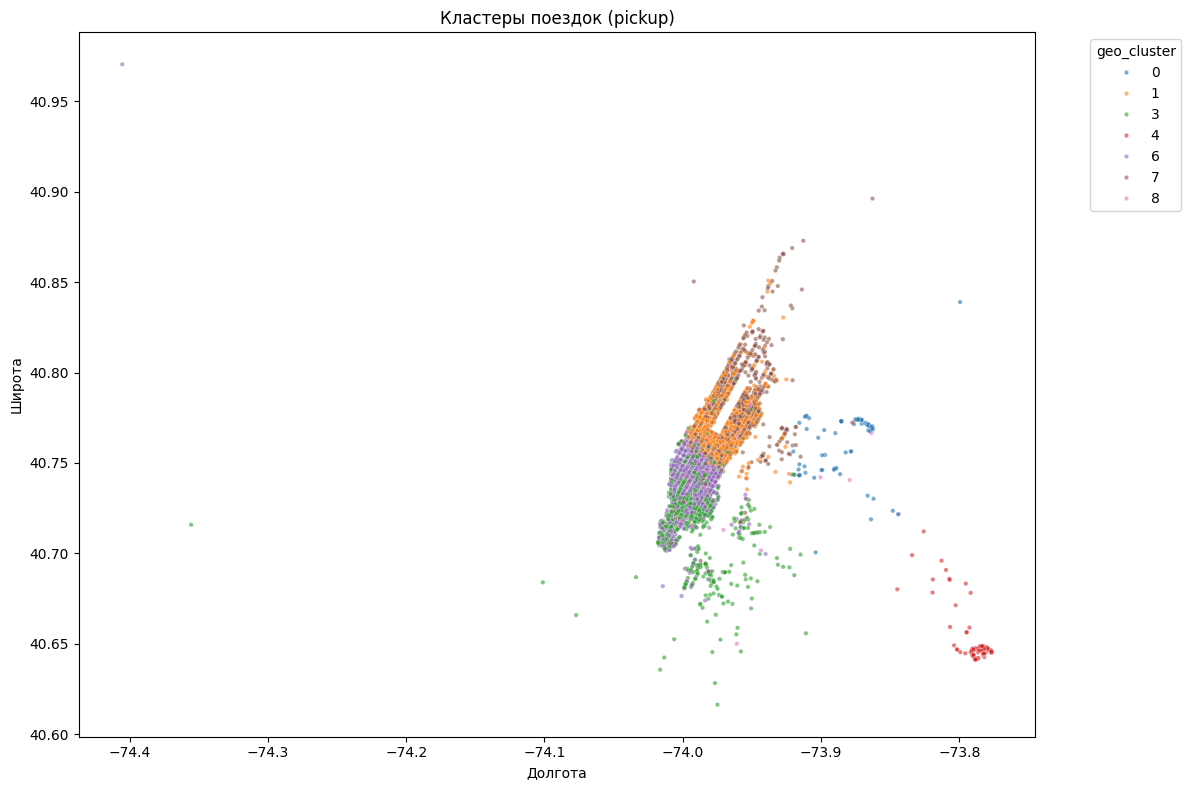

In [ ]:
# Визуализация кластеризации
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=taxi_train.sample(min(10000, len(taxi_train)), random_state=42),
    x='pickup_longitude',
    y='pickup_latitude',
    hue='geo_cluster',
    palette='tab10',
    s=10,
    alpha=0.6,
    legend='full'
)
plt.title('Кластеры поездок (pickup)')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.legend(title='geo_cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Сохраняем график
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
plot_filename = f"{timestamp}_clusters.png"
plot_path = os.path.join(output_dir, plot_filename)

plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Логируем эксперимент
log_experiment(
    name="clusters",
    params={
        "type": "EDA",
        "method": "kmeans",
        "n_clusters": int(taxi_train['geo_cluster'].nunique()),
        "sample_size": min(10000, len(taxi_train)),
    },
    metrics={
        "n_clusters": int(taxi_train['geo_cluster'].nunique()),
        "cluster_distribution": taxi_train['geo_cluster'].value_counts().to_dict(),
        "total_rows": int(len(taxi_train)),
    },
    features=['pickup_longitude', 'pickup_latitude', 'geo_cluster'],
    output_dir=output_dir,
    artifact_path=plot_path,
);

>Вывод: изначальная кластеризация подразумевала 10 кластеров. После удаления выбросов количество уменьшилось до 9

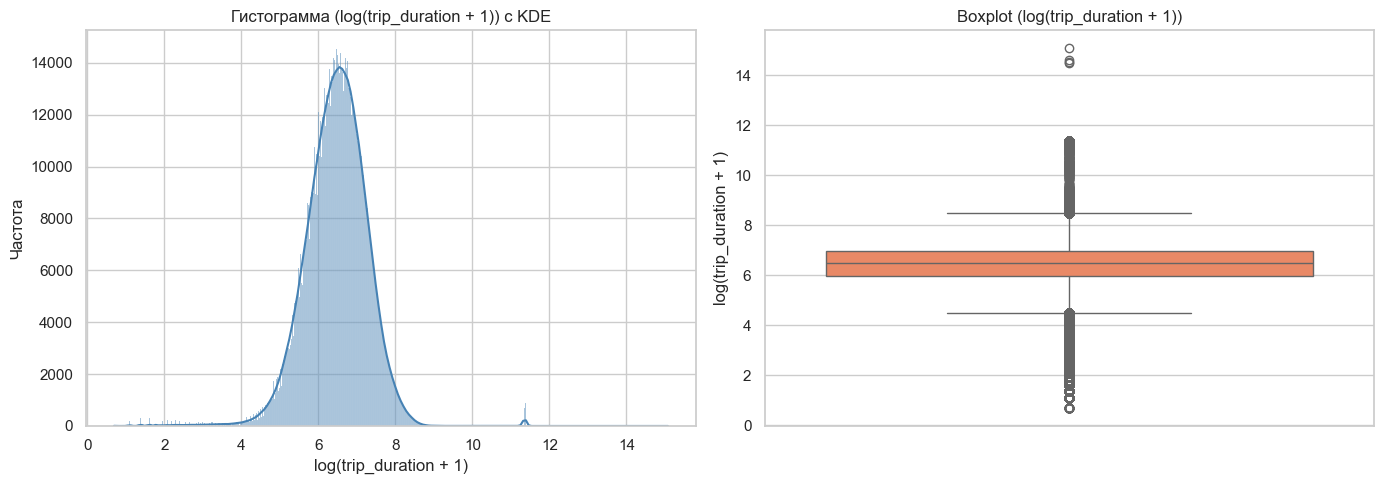

In [18]:
# Распределение целевой переменной
sns.set(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма с KDE
sns.histplot(
    data=taxi_train,
    x='trip_duration_log',
    kde=True,
    ax=ax[0],
    color='steelblue'
)
ax[0].set_title('Гистограмма (log(trip_duration + 1)) с KDE')
ax[0].set_xlabel('log(trip_duration + 1)')
ax[0].set_ylabel('Частота')

# Коробчатая диаграмма (boxplot)
sns.boxplot(
    y=taxi_train['trip_duration_log'],
    ax=ax[1],
    color='coral'
)
ax[1].set_title('Boxplot (log(trip_duration + 1))')
ax[1].set_ylabel('log(trip_duration + 1)')

plt.tight_layout()

# Сохраняем график
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
plot_filename = f"{timestamp}_target_distribution.png"
plot_path = os.path.join(output_dir, plot_filename)

plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Логируем эксперимент
log_experiment(
    name="target_distribution",
    params={
        "type": "EDA",
        "target": "trip_duration_log",
        "transform": "log1p",
    },
    metrics={
        "mean": float(taxi_train['trip_duration_log'].mean()),
        "median": float(taxi_train['trip_duration_log'].median()),
        "std": float(taxi_train['trip_duration_log'].std()),
        "skew": float(taxi_train['trip_duration_log'].skew()),
        "total_rows": int(len(taxi_train)),
    },
    features=['pickup_longitude', 'pickup_latitude', 'geo_cluster'],
    output_dir=output_dir,
    artifact_path=plot_path,
);

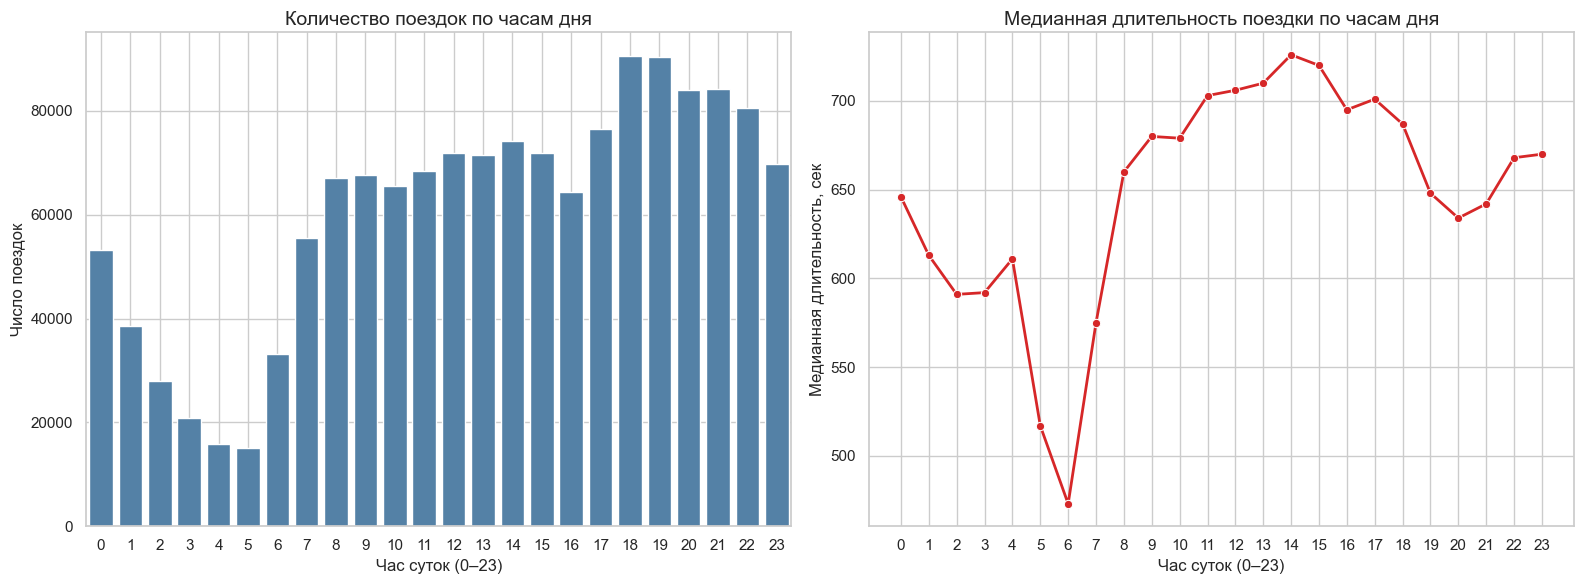

In [19]:
# График количество поездок по часам и медианная длительность по часам
taxi_train['pickup_hour'] = taxi_train['pickup_hour'].astype(int)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Количество поездок по часам
hour_counts = taxi_train['pickup_hour'].value_counts().sort_index()

sns.barplot(
    x=hour_counts.index,
    y=hour_counts.values,
    ax=ax[0],
    color='steelblue'
)
ax[0].set_title('Количество поездок по часам дня', fontsize=14)
ax[0].set_xlabel('Час суток (0–23)')
ax[0].set_ylabel('Число поездок')
ax[0].set_xticks(range(0, 24, 1))
ax[0].grid(True)

# Медианная длительность по часам
median_duration_by_hour = taxi_train.groupby('pickup_hour')['trip_duration'].median()

sns.lineplot(
    x=median_duration_by_hour.index,
    y=median_duration_by_hour.values,
    marker='o',
    linewidth=2,
    markersize=6,
    ax=ax[1],
    color='#d62728'
)
ax[1].set_title('Медианная длительность поездки по часам дня', fontsize=14)
ax[1].set_xlabel('Час суток (0–23)')
ax[1].set_ylabel('Медианная длительность, сек')
ax[1].set_xticks(range(0, 24, 1))

plt.tight_layout()

# Сохраняем график
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
plot_filename = f"{timestamp}_hourly_trips.png"
plot_path = os.path.join(output_dir, plot_filename)

plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Логируем эксперимент
log_experiment(
    name="hourly_trips",
    params={
        "type": "EDA",
        "feature": "pickup_hour",
        "agg": "count + median",
    },
    metrics={
        "peak_hour_count": int(hour_counts.idxmax()),
        "peak_hour_trips": int(hour_counts.max()),
        "peak_hour_median_duration": int(median_duration_by_hour.idxmax()),
        "max_median_duration_sec": float(median_duration_by_hour.max()),
        "total_rows": int(len(taxi_data)),
    },
    features=['pickup_hour', 'trip_duration'],
    output_dir=output_dir,
    artifact_path=plot_path,
);

>Вывод: пиковая загрузка по поездкам с 17 до 22 часов, минимальная загрузка - с 3 ночи до 5 утра. Максимальная длительность поездки с 13 до 15 часов. Минимальная с 5 до 7 утра

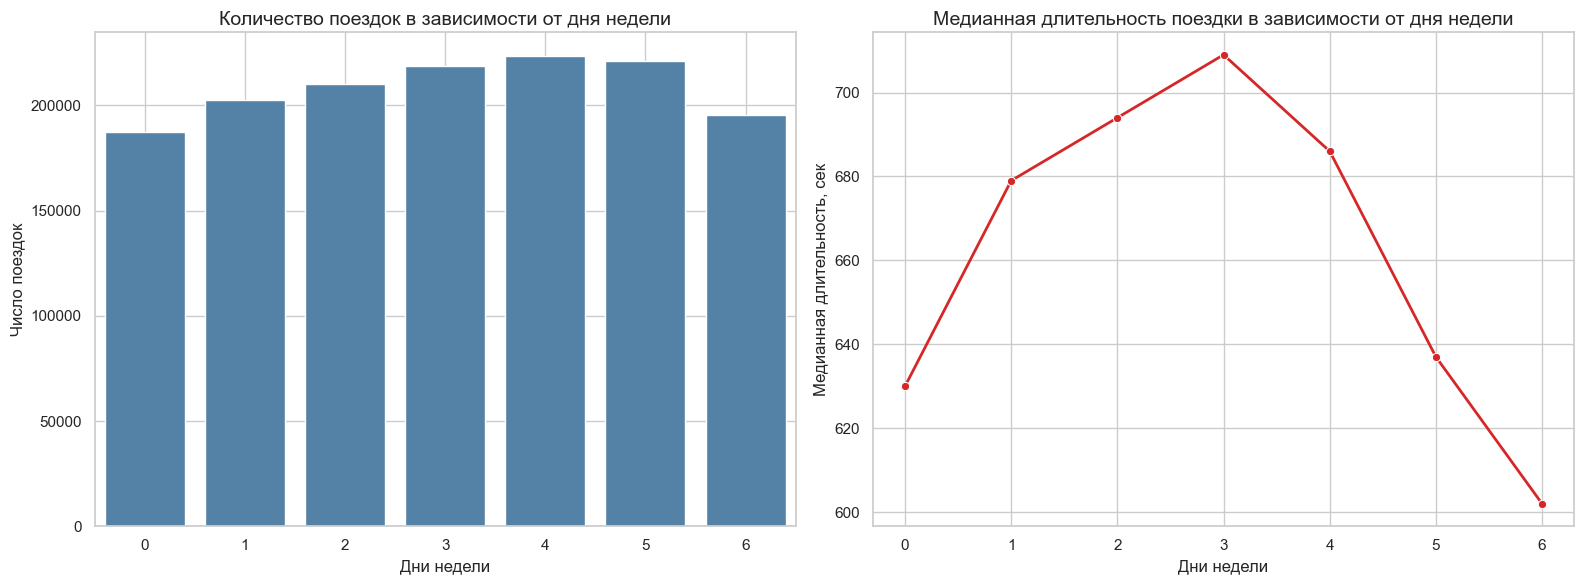

In [ ]:
# Распределение количества поездок по дням недели и медианная длительность по дням недели
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Количество поездок по дням недели
day_counts = taxi_train['pickup_day_of_week'].value_counts().sort_index()

sns.barplot(
    x=day_counts.index,
    y=day_counts.values,
    ax=ax[0],
    color='steelblue'
)
ax[0].set_title('Количество поездок в зависимости от дня недели', fontsize=14)
ax[0].set_xlabel('Дни недели')
ax[0].set_ylabel('Число поездок')
ax[0].set_xticks(range(0, 7, 1))
ax[0].grid(True)

# Медианная длительность по дням недели
median_duration_by_day = taxi_train.groupby('pickup_day_of_week')['trip_duration'].median()

sns.lineplot(
    x=median_duration_by_day.index,
    y=median_duration_by_day.values,
    marker='o',
    linewidth=2,
    markersize=6,
    ax=ax[1],
    color='#d62728'
)
ax[1].set_title('Медианная длительность поездки в зависимости от дня недели', fontsize=14)
ax[1].set_xlabel('Дни недели')
ax[1].set_ylabel('Медианная длительность, сек')
ax[1].set_xticks(range(0, 7, 1))

plt.tight_layout()

# Сохраняем график
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
plot_filename = f"{timestamp}_day_of_week_trips.png"
plot_path = os.path.join(output_dir, plot_filename)

plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Логируем эксперимент
log_experiment(
    name="day_of_week_trips",
    params={
        "type": "EDA",
        "feature": "pickup_day_of_week",
        "agg": "count + median",
    },
    metrics={
        "peak_day_count": int(day_counts.idxmax()),
        "peak_day_trips": int(day_counts.max()),
        "peak_day_median_duration": int(median_duration_by_day.idxmax()),
        "max_median_duration_sec": float(median_duration_by_day.max()),
        "total_rows": int(len(taxi_data)),
    },
    features=['pickup_day_of_week', 'trip_duration'],
    output_dir=output_dir,
    artifact_path=plot_path,
);

>Вывод: максимальное количество поездок на такси в пятницу. Максимальная длительность поездки в четверг

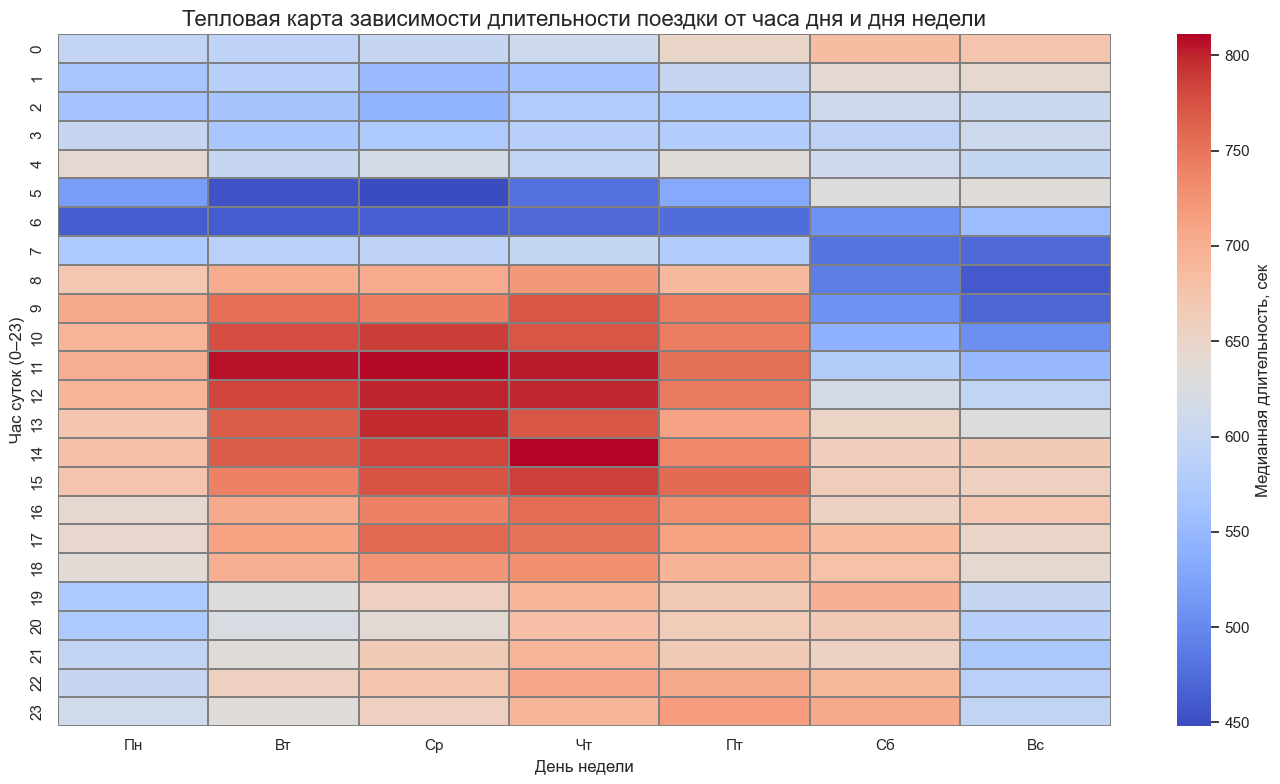

In [21]:
# Тепловая карта зависимости длительности поездки от часа дня и дня недели
pivot = taxi_train.pivot_table(
    values='trip_duration',
    index='pickup_hour',
    columns='pickup_day_of_week',
    aggfunc='median',
    fill_value=None
)

day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
pivot = pivot.rename(columns=day_names)

plt.figure(figsize=(14, 8))
heatmap = sns.heatmap(
    data=pivot,
    cmap='coolwarm',
    annot=False,
    cbar_kws={'label': 'Медианная длительность, сек'},
    linewidths=0.1,
    linecolor='gray',
    mask=pivot.isna()
)

heatmap.set_title('Тепловая карта зависимости длительности поездки от часа дня и дня недели', fontsize=16)
heatmap.set_xlabel('День недели', fontsize=12)
heatmap.set_ylabel('Час суток (0–23)', fontsize=12)

plt.tight_layout()

# Сохраняем график
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
plot_filename = f"{timestamp}_heatmap_hour_dow.png"
plot_path = os.path.join(output_dir, plot_filename)

plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Логируем эксперимент
log_experiment(
    name="heatmap_hour_dow",
    params={
        "type": "EDA",
        "features": "pickup_hour + pickup_day_of_week",
        "agg": "median",
    },
    metrics={
        "max_median_duration_sec": float(pivot.max().max()),
        "min_median_duration_sec": float(pivot.min().min()),
        "total_cells": int(pivot.size),
        "total_rows": int(len(taxi_data)),
    },
    features=['pickup_hour', 'pickup_day_of_week', 'trip_duration'],
    output_dir=output_dir,
    artifact_path=plot_path,
);

>Вывод: максимальная длительность поездок со вторника по четверг с 10 до 15 часов

C:\Users\PC\AppData\Local\Temp\ipykernel_21912\3113713231.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


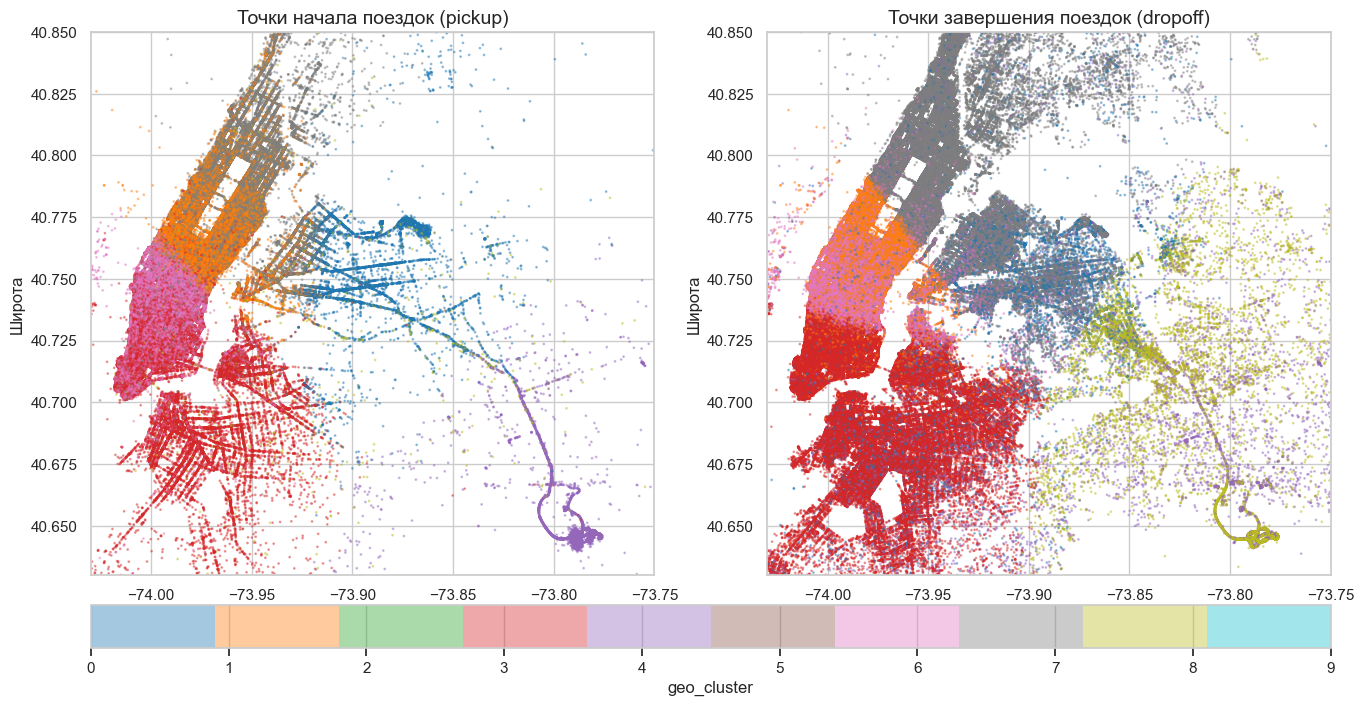

In [22]:
# Распределение по кластерам начальных и финальных точек поездок
city_long_border = (-74.03, -73.75)
city_lat_border = (40.63, 40.85)

fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.08], wspace=0.2, hspace=0.1)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[1, :])

scatter1 = ax1.scatter(
    taxi_train['pickup_longitude'],
    taxi_train['pickup_latitude'],
    c=taxi_train['geo_cluster'],
    cmap='tab10',
    s=1,
    alpha=0.4
)
ax1.set_xlim(city_long_border)
ax1.set_ylim(city_lat_border)
ax1.set_title('Точки начала поездок (pickup)', fontsize=14)
ax1.set_xlabel('Долгота')
ax1.set_ylabel('Широта')

scatter2 = ax2.scatter(
    taxi_train['dropoff_longitude'],
    taxi_train['dropoff_latitude'],
    c=taxi_train['geo_cluster'],
    cmap='tab10',
    s=1,
    alpha=0.4
)
ax2.set_xlim(city_long_border)
ax2.set_ylim(city_lat_border)
ax2.set_title('Точки завершения поездок (dropoff)', fontsize=14)
ax2.set_xlabel('Долгота')
ax2.set_ylabel('Широта')

cbar = fig.colorbar(scatter2, cax=cax, orientation='horizontal')
cbar.set_label('geo_cluster', fontsize=12)
cbar.set_ticks(range(10))

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Сохраняем график
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
plot_filename = f"{timestamp}_pickup_dropoff_scatter.png"
plot_path = os.path.join(output_dir, plot_filename)

plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Логируем эксперимент
log_experiment(
    name="pickup_dropoff_scatter",
    params={
        "type": "EDA",
        "features": "pickup + dropoff coordinates",
        "color_by": "geo_cluster",
        "n_clusters": int(taxi_data['geo_cluster'].nunique()),
    },
    metrics={
        "pickup_long_range": [float(taxi_train['pickup_longitude'].min()), float(taxi_train['pickup_longitude'].max())],
        "pickup_lat_range": [float(taxi_train['pickup_latitude'].min()), float(taxi_train['pickup_latitude'].max())],
        "dropoff_long_range": [float(taxi_train['dropoff_longitude'].min()), float(taxi_train['dropoff_longitude'].max())],
        "dropoff_lat_range": [float(taxi_train['dropoff_latitude'].min()), float(taxi_train['dropoff_latitude'].max())],
        "total_rows": int(len(taxi_train)),
    },
    features=['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'geo_cluster'],
    output_dir=output_dir,
    artifact_path=plot_path,
);

>Вывод: по этому графику удобно интепретировать в каких кластерах(районах города) больше начинаются поездки, а где меньше. Также и с завершением поездок

---

### Подготовка признаков к моделированию

In [23]:
numeric_features = [
    'haversine_distance', 'direction', 'total_distance', 'total_travel_time',
    'number_of_steps', 'temperature', 'visibility', 'wind speed', 'precip',
    'passenger_count', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
]

binary_features = ['is_weekend', 'is_rush_hour', 'is_holiday']

categorical_onehot = [
    'vendor_id', 'store_and_fwd_flag', 'events', 'geo_cluster',
    'pickup_hour', 'pickup_day_of_week',
]

feature_cols = numeric_features + binary_features + categorical_onehot

### Формируем X и y

In [24]:
# 1. Выделяем признаки и таргет
X = taxi_train[feature_cols]
y = np.log1p(taxi_train['trip_duration'])

# 2. Сначала отделяем holdout (наш внутренний "финальный" тест, 20%)
# На нём мы будем делать финальную оценку перед тем, как идти на настоящий внешний тест
X_temp, X_holdout, y_temp, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 3. Теперь делим остаток на train и valid (для подбора гиперпараметров)
# valid будет 25% от остатка (то есть ~16% от всего)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Valid: {X_valid.shape[0]} строк")
print(f"Holdout: {X_holdout.shape[0]} строк")


Train: 875186 строк
Valid: 291729 строк
Holdout: 291729 строк


### Подготовка универсального preprocessor = ColumnTransformer и Baseline  на LinearRegression

In [25]:
# Препроцессор (универсальный, подойдёт и для линейных, и для деревьев)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat_oh', OneHotEncoder(handle_unknown='ignore'), categorical_onehot)
    ]
)

# Пайплайн: предобработка + линейная регрессия
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

# Обучаем на train
pipeline.fit(X_train, y_train)

# Прогноз на valid и holdout (в логарифмах)
y_pred_valid_log = pipeline.predict(X_valid)
y_pred_holdout_log = pipeline.predict(X_holdout)

# Считаем метрику
rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"RMSLE на валидации: {rmsle_valid:.4f}")
print(f"RMSLE на холд‑ауте: {rmsle_holdout:.4f}")

# Логируем эксперимент
log_experiment(
    name="baseline_linear_regression",
    params={
        "model_type": "baseline",
        "model": "LinearRegression",
        "preprocess": "StandardScaler + passthrough + OneHotEncoder",
        "target": "log1p(trip_duration)",
        "feature_selection": "none (all features)",
        "n_features": len(feature_cols),
    },
    metrics={
        "rmsle_valid": float(rmsle_valid),
        "rmsle_holdout": float(rmsle_holdout),
        "train_rows": int(X_train.shape[0]),
        "valid_rows": int(X_valid.shape[0]),
        "holdout_rows": int(X_holdout.shape[0]),
    },
    features=feature_cols,
    output_dir=output_dir,
);

RMSLE на валидации: 0.5164
RMSLE на холд‑ауте: 0.5182


### Пайплайн PolynomialFeatures(degree=2), Ridge(alpha=1.0)

In [26]:
pipeline_ridge = Pipeline([
    ('preprocess', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge(alpha=1.0))
])

pipeline_ridge.fit(X_train, y_train)

y_pred_train_log   = pipeline_ridge.predict(X_train)
y_pred_valid_log   = pipeline_ridge.predict(X_valid)
y_pred_holdout_log = pipeline_ridge.predict(X_holdout)

rmsle_train   = calc_rmsle_from_log(y_train, y_pred_train_log)
rmsle_valid   = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"Ridge+Poly RMSLE train:   {rmsle_train:.4f}")
print(f"Ridge+Poly RMSLE valid:   {rmsle_valid:.4f}")
print(f"Ridge+Poly RMSLE holdout: {rmsle_holdout:.4f}")

# Логируем эксперимент
log_experiment(
    name="ridge_poly_alpha1",
    params={
        "model_type": "Ridge+PolynomialFeatures",
        "preprocess": "StandardScaler + passthrough + OneHotEncoder",
        "target": "log1p(trip_duration)",
        "feature_selection": "none (all features)",
        "n_features": len(feature_cols),
        "poly_degree": 2,
        "alpha": 1.0,
    },
    metrics={
        "rmsle_train": float(rmsle_train),
        "rmsle_valid": float(rmsle_valid),
        "rmsle_holdout": float(rmsle_holdout),
    },
    features=feature_cols,
    output_dir=output_dir,
    baseline_rmsle=0.5164,
);

Ridge+Poly RMSLE train:   0.4535
Ridge+Poly RMSLE valid:   0.4542
Ridge+Poly RMSLE holdout: 0.4583


### Пайплайн DecisionTreeRegressor с подбором оптимальной max_depth 

Оптимальная глубина: 11, 
RMSLE valid: 0.4325
RMSLE holdout: 0.4337


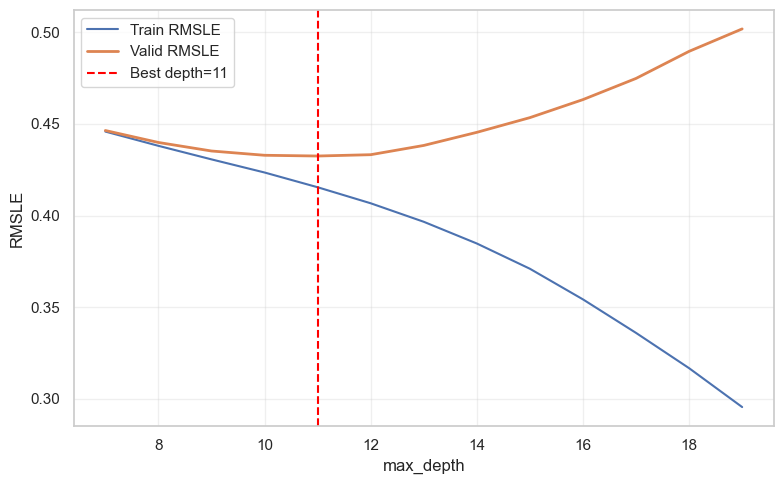

In [27]:
max_depths = range(7, 20)
valid_scores = []
train_scores = []

for d in max_depths:
    dt_pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    dt_pipeline.fit(X_train, y_train)

    y_pred_train_log = dt_pipeline.predict(X_train)
    y_pred_valid_log = dt_pipeline.predict(X_valid)

    train_scores.append(calc_rmsle_from_log(y_train, y_pred_train_log))
    valid_scores.append(calc_rmsle_from_log(y_valid, y_pred_valid_log))

best_idx = np.argmin(valid_scores)
best_depth = max_depths[best_idx]
print(f"Оптимальная глубина: {best_depth}, \nRMSLE valid: {valid_scores[best_idx]:.4f}")

# Оценка на holdout с лучшей глубиной
dt_best = Pipeline([
    ('preprocess', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=best_depth, random_state=42))
])
dt_best.fit(X_train, y_train)
y_pred_holdout_log = dt_best.predict(X_holdout)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"RMSLE holdout: {rmsle_holdout:.4f}")

# График
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(max_depths), train_scores, label='Train RMSLE')
ax.plot(list(max_depths), valid_scores, label='Valid RMSLE', linewidth=2)
ax.axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('RMSLE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Сохраняем график
artifact_path = os.path.join(output_dir, "decision_tree_depth_curve.png")
plt.savefig(artifact_path, dpi=150)
plt.show()

# Логируем эксперимент
log_experiment(
    name="decision_tree_depth_search",
    params={
        "model_type": "DecisionTreeRegressor",
        "preprocess": "StandardScaler + passthrough + OneHotEncoder",
        "target": "log1p(trip_duration)",
        "feature_selection": "none (all features)",
        "n_features": len(feature_cols),
        "max_depth": best_depth,
        "random_state": 42,
    },
    metrics={
        "rmsle_train": float(train_scores[best_idx]),
        "rmsle_valid": float(valid_scores[best_idx]),
        "rmsle_holdout": float(rmsle_holdout),
    },
    features=feature_cols,
    output_dir=output_dir,
    baseline_rmsle=0.5164,
    artifact_path=artifact_path,
);

### Пайплайн RandomForestRegressor

In [28]:
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_train_log = rf_pipeline.predict(X_train)
y_pred_valid_log = rf_pipeline.predict(X_valid)
y_pred_holdout_log = rf_pipeline.predict(X_holdout)

rmsle_train = calc_rmsle_from_log(y_train, y_pred_train_log)
rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"RandomForest RMSLE train:   {rmsle_train:.4f}")
print(f"RandomForest RMSLE valid:   {rmsle_valid:.4f}")
print(f"RandomForest RMSLE holdout: {rmsle_holdout:.4f}")

# Логируем эксперимент
log_experiment(
    name="random_forest_all_features",
    params={
        "model_type": "RandomForestRegressor",
        "preprocess": "StandardScaler + passthrough + OneHotEncoder",
        "target": "log1p(trip_duration)",
        "feature_selection": "none (all features)",
        "n_features": len(feature_cols),
        "n_estimators": 200,
        "max_depth": 12,
        "random_state": 42,
    },
    metrics={
        "rmsle_train": float(rmsle_train),
        "rmsle_valid": float(rmsle_valid),
        "rmsle_holdout": float(rmsle_holdout),
    },
    features=feature_cols,
    output_dir=output_dir,
    baseline_rmsle=0.5164,
);

RandomForest RMSLE train:   0.3961
RandomForest RMSLE valid:   0.4162
RandomForest RMSLE holdout: 0.4184


### Ранжируем признаки (потенциально, чтобы отобрать 25 самых важных)

In [29]:
importances = rf_pipeline.named_steps['model'].feature_importances_
preprocessor = rf_pipeline.named_steps['preprocess']

# Собираем имена всех признаков после препроцессора
feature_names = []

# numeric — как есть
feature_names.extend(numeric_features)

# binary — как есть
feature_names.extend(binary_features)

# categorical OneHot — раскрываются на несколько колонок
ohe = preprocessor.named_transformers_['cat_oh']
ohe_names = ohe.get_feature_names_out(categorical_onehot)
feature_names.extend(ohe_names)

# Создаём DataFrame: признак → важность
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Маппим каждый OHE-признак обратно к исходной колонке
def map_to_original(name):
    for cat in categorical_onehot:
        if name.startswith(cat + '_') or name == cat:
            return cat
    return name

importance_df['source'] = importance_df['feature'].apply(map_to_original)

# Суммируем важности по исходным колонкам
grouped = importance_df.groupby('source')['importance'].sum().sort_values(ascending=False)

# Топ-25 исходных признаков
top_25_features = grouped.head(25).index.tolist()

print("Топ-25 признаков:")
for i, feat in enumerate(top_25_features, 1):
    print(f"  {i:2d}. {feat:30s} {grouped[feat]:.4f}")

# Новый список для всех последующих моделей
feature_cols_25 = top_25_features
print(f"\nfeature_cols_25 = {feature_cols_25}")

Топ-25 признаков:
   1. total_distance                 0.6790
   2. total_travel_time              0.1703
   3. haversine_distance             0.0273
   4. hour_cos                       0.0273
   5. hour_sin                       0.0208
   6. geo_cluster                    0.0190
   7. direction                      0.0131
   8. dow_sin                        0.0103
   9. is_weekend                     0.0053
  10. vendor_id                      0.0050
  11. pickup_hour                    0.0041
  12. temperature                    0.0037
  13. number_of_steps                0.0030
  14. dow_cos                        0.0029
  15. is_holiday                     0.0015
  16. passenger_count                0.0015
  17. is_rush_hour                   0.0015
  18. pickup_day_of_week             0.0015
  19. wind speed                     0.0014
  20. visibility                     0.0007
  21. precip                         0.0003
  22. events                         0.0002
  23. store_an

>Вывод: два признака забрали 85% важности: total_distance (0.68) и total_travel_time (0.17)

Что это значит:
* OSRM-признаки — ядро модели. Без них всё развалится.
* Погода (precip, events, visibility) почти не влияет — можно попробовать выбросить и проверить, не улучшит ли это результат (меньше шума).
* store_and_fwd_flag = 0.000 — мёртвый признак, можно смело удалить.
* Временные признаки (hour_sin/cos, dow_sin/cos, is_weekend, is_rush_hour) — collectively дают ~7%, по отдельности мелкие, но вместе значимы.

### Пайплайн GradientBoostingRegressor

In [30]:
gb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(
        learning_rate=0.5,
        n_estimators=100,
        max_depth=6,
        min_samples_split=30,
        random_state=42,
        verbose=1,
    ))
])

gb_pipeline.fit(X_train, y_train)

y_pred_train_log = gb_pipeline.predict(X_train)
y_pred_valid_log = gb_pipeline.predict(X_valid)
y_pred_holdout_log = gb_pipeline.predict(X_holdout)

rmsle_train = calc_rmsle_from_log(y_train, y_pred_train_log)
rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"GradientBoosting RMSLE train:   {rmsle_train:.4f}")
print(f"GradientBoosting RMSLE valid:   {rmsle_valid:.4f}")
print(f"GradientBoosting RMSLE holdout: {rmsle_holdout:.4f}")

# Логируем эксперимент
log_experiment(
    name="gradient_boosting_baseline",
    params={
        "model_type": "GradientBoostingRegressor",
        "preprocess": "StandardScaler + passthrough + OneHotEncoder",
        "target": "log1p(trip_duration)",
        "feature_selection": "none (all features)",
        "n_features": len(feature_cols),
        "learning_rate": 0.5,
        "n_estimators": 100,
        "max_depth": 6,
        "min_samples_split": 30,
        "random_state": 42,
    },
    metrics={
        "rmsle_train": float(rmsle_train),
        "rmsle_valid": float(rmsle_valid),
        "rmsle_holdout": float(rmsle_holdout),
    },
    features=feature_cols,
    output_dir=output_dir,
    baseline_rmsle=0.5164,
);

      Iter       Train Loss   Remaining Time 
         1           0.3139           16.48m
         2           0.2260           16.26m
         3           0.1989           16.45m
         4           0.1880           16.21m
         5           0.1828           15.89m
         6           0.1790           15.66m
         7           0.1765           15.60m
         8           0.1748           15.44m
         9           0.1732           15.30m
        10           0.1718           15.16m
        20           0.1649           13.28m
        30           0.1612           12.57m
        40           0.1583           10.63m
        50           0.1565            8.57m
        60           0.1547            6.71m
        70           0.1530            4.96m
        80           0.1514            3.27m
        90           0.1500            1.62m
       100           0.1489            0.00s
GradientBoosting RMSLE train:   0.3858
GradientBoosting RMSLE valid:   0.4077
GradientBoosting RMSL

### Пайплайн HistGradientBoostingRegressor

In [31]:
preprocessor_ordinal = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('bin', 'passthrough', binary_features),
    ('cat_oh', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_onehot)
])

hgb_pipeline = Pipeline([
    ('preprocess', preprocessor_ordinal),
    ('model', HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_depth=None,
        min_samples_leaf=30,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42,
        verbose=1,
    ))
])

hgb_pipeline.fit(X_train, y_train)

y_pred_train_log = hgb_pipeline.predict(X_train)
y_pred_valid_log = hgb_pipeline.predict(X_valid)
y_pred_holdout_log = hgb_pipeline.predict(X_holdout)

rmsle_train = calc_rmsle_from_log(y_train, y_pred_train_log)
rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"HistGBM RMSLE train:   {rmsle_train:.4f}")
print(f"HistGBM RMSLE valid:   {rmsle_valid:.4f}")
print(f"HistGBM RMSLE holdout: {rmsle_holdout:.4f}")

# Логируем эксперимент
log_experiment(
    name="hist_gradient_boosting",
    params={
        "model_type": "HistGradientBoostingRegressor",
        "preprocess": "StandardScaler + passthrough + OrdinalEncoder",
        "target": "log1p(trip_duration)",
        "feature_selection": "none (all features)",
        "n_features": len(feature_cols),
        "max_iter": 500,
        "learning_rate": 0.05,
        "min_samples_leaf": 30,
        "l2_regularization": 1.0,
        "early_stopping": True,
        "n_iter_no_change": 30,
        "random_state": 42,
    },
    metrics={
        "rmsle_train": float(rmsle_train),
        "rmsle_valid": float(rmsle_valid),
        "rmsle_holdout": float(rmsle_holdout),
    },
    features=feature_cols,
    output_dir=output_dir,
    baseline_rmsle=0.5164,
);

Binning 0.145 GB of training data: 0.354 s
Binning 0.016 GB of validation data: 0.009 s
Fitting gradient boosted rounds:
[1/500] 1 tree, 31 leaves, max depth = 6, train loss: 0.29616, val loss: 0.29713, in 0.061s
[2/500] 1 tree, 31 leaves, max depth = 6, train loss: 0.27785, val loss: 0.27879, in 0.056s
[3/500] 1 tree, 31 leaves, max depth = 7, train loss: 0.26123, val loss: 0.26215, in 0.053s
[4/500] 1 tree, 31 leaves, max depth = 7, train loss: 0.24619, val loss: 0.24710, in 0.049s
[5/500] 1 tree, 31 leaves, max depth = 7, train loss: 0.23255, val loss: 0.23345, in 0.048s
[6/500] 1 tree, 31 leaves, max depth = 7, train loss: 0.22020, val loss: 0.22107, in 0.051s
[7/500] 1 tree, 31 leaves, max depth = 7, train loss: 0.20896, val loss: 0.20982, in 0.047s
[8/500] 1 tree, 31 leaves, max depth = 7, train loss: 0.19881, val loss: 0.19966, in 0.049s
[9/500] 1 tree, 31 leaves, max depth = 7, train loss: 0.18957, val loss: 0.19042, in 0.048s
[10/500] 1 tree, 31 leaves, max depth = 7, train lo

### Пайплайн VotingRegressor

In [32]:
voting = VotingRegressor([
    ('ridge_poly', Pipeline([
        ('preprocess', preprocessor),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('model', Ridge(alpha=1.0))
    ])),
    ('rf', Pipeline([
        ('preprocess', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))
    ])),
    ('hgb', Pipeline([
        ('preprocess', preprocessor_ordinal),
        ('model', HistGradientBoostingRegressor(
            max_iter=500, learning_rate=0.05, min_samples_leaf=30,
            l2_regularization=1.0, early_stopping=True, n_iter_no_change=30,
            random_state=42,
        ))
    ]))
])

voting.fit(X_train, y_train)

y_pred_train_log = voting.predict(X_train)
y_pred_valid_log = voting.predict(X_valid)
y_pred_holdout_log = voting.predict(X_holdout)

rmsle_train = calc_rmsle_from_log(y_train, y_pred_train_log)
rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"Voting RMSLE train:   {rmsle_train:.4f}")
print(f"Voting RMSLE valid:   {rmsle_valid:.4f}")
print(f"Voting RMSLE holdout: {rmsle_holdout:.4f}")

# Логируем эксперимент
log_experiment(
    name="voting_ridge_rf_hgbm",
    params={
        "model_type": "VotingRegressor",
        "estimators": "Ridge+Poly2, RandomForest, HistGBM",
        "voting": "uniform (equal weights)",
        "target": "log1p(trip_duration)",
        "feature_selection": "none (all features)",
        "n_features": len(feature_cols),
        "random_state": 42,
    },
    metrics={
        "rmsle_train": float(rmsle_train),
        "rmsle_valid": float(rmsle_valid),
        "rmsle_holdout": float(rmsle_holdout),
    },
    features=feature_cols,
    output_dir=output_dir,
    baseline_rmsle=0.5164,
);

Voting RMSLE train:   0.4027
Voting RMSLE valid:   0.4120
Voting RMSLE holdout: 0.4142


### Загрузка и подготовка тестовых данных

In [33]:
# 1. Загрузка тестовых данных
test_data = pd.read_csv("../data/Project5_test_data.csv")
osrm_data_test = pd.read_csv("../data/Project5_osrm_data_test.csv")
test_id = test_data['id'].copy()

# 2. Предобработка тестовых данных
if 'pickup_datetime' in test_data.columns:
    test_data['pickup_datetime'] = pd.to_datetime(test_data['pickup_datetime'])
if 'dropoff_datetime' in test_data.columns:
    test_data['dropoff_datetime'] = pd.to_datetime(test_data['dropoff_datetime'])


test_data = add_holiday_features(test_data, holiday_data)
test_data = add_osrm_features(test_data, osrm_data_test)
test_data = add_geographical_features(test_data)
test_data = add_datetime_features(test_data)

test_data = add_cluster_features(test_data, kmeans)

test_data = add_temporal_cyclic_features(test_data)
test_data = add_weather_features(test_data, weather_data)

# Заполняем пропуски 
test_data = fill_null_weather_data(test_data)
print(f"Всего пропусков: {test_data.isnull().sum().sum()}")

X_test = test_data[feature_cols].copy()

print("X_test shape:", X_test.shape)
print("X_train shape:", X_train.shape)


Всего пропусков: 0
X_test shape: (625134, 23)
X_train shape: (875186, 23)


### Обучение полного набора данных на лучшей модели

In [34]:
# Объединяем все данные
X_full = pd.concat([X_train, X_valid, X_holdout], axis=0)
y_full = pd.concat([y_train, y_valid, y_holdout], axis=0)

print(f"Обучаем на всём объёме: {X_full.shape}")

# Обучаем пайплайн заново на полном датасете
gb_pipeline.fit(X_full, y_full)

# Предсказание
y_pred_log = gb_pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_pred = np.maximum(y_pred, 1)

submission = pd.DataFrame({
    'id': test_id,
    'trip_duration': y_pred
})

submission.to_csv('../experiments/submission.csv', index=False)
print("Сабмишн готов! Строк:", len(submission))

Обучаем на всём объёме: (1458644, 23)
      Iter       Train Loss   Remaining Time 
         1           0.3143           27.67m
         2           0.2274           26.67m
         3           0.1993           26.37m
         4           0.1886           25.96m
         5           0.1825           25.42m
         6           0.1791           25.30m
         7           0.1763           24.90m
         8           0.1747           24.69m
         9           0.1732           24.67m
        10           0.1722           24.47m
        20           0.1660           22.48m
        30           0.1632           19.64m
        40           0.1609           16.81m
        50           0.1590           13.99m
        60           0.1573           11.19m
        70           0.1560            8.43m
        80           0.1546            5.64m
        90           0.1534            2.85m
       100           0.1522            0.00s
Сабмишн готов! Строк: 625134


In [35]:
# финальный лог
log_experiment(
    name="final_submission_hist_gbm",
    params={
        "model_type": "HistGradientBoostingRegressor",
        "preprocess": "StandardScaler + passthrough + OrdinalEncoder",
        "target": "log1p(trip_duration)",
        "n_features": len(feature_cols),
        "max_iter": 500,
        "learning_rate": 0.05,
        "min_samples_leaf": 30,
        "l2_regularization": 1.0,
        "early_stopping": True,
        "n_iter_no_change": 30,
        "random_state": 42,
        "trained_on": "full_dataset",
        "leaderboard_private": 0.40990,
    },

metrics={
    "best_valid_rmsle": 0.4046,
    "best_holdout_rmsle": 0.4060,
    "leaderboard_public": 0.41257,
    "leaderboard_private": 0.40902,
},
    features=feature_cols,
    output_dir=output_dir,
    baseline_rmsle=0.5164,
)

print("Финальный лог сохранён. Проект завершён!")

Финальный лог сохранён. Проект завершён!
